# Step 5 — Baseline Model Comparison

To justify the use of CatBoost, we compare it against three standard baselines:
- **Logistic Regression** — linear, interpretable, widely used in credit risk literature
- **Decision Tree** — simple non-linear model, fully interpretable
- **Random Forest** — strong ensemble baseline, comparable family to CatBoost

All models use the same temporal train/test split. Evaluation uses AUC, Brier Score, and Failed-class F1 at threshold 0.4.

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, roc_curve,
    precision_score, recall_score, f1_score, classification_report
)

print('All imports successful!')

All imports successful!


In [2]:
df = pd.read_csv('../data/american_bankruptcy_dataset.csv')
df['target'] = (df['status_label'] == 'failed').astype(int)

train_df = df[df['fyear'] <= 2011]
val_df   = df[(df['fyear'] >= 2012) & (df['fyear'] <= 2014)]
test_df  = df[df['fyear'] >= 2015]

FEATURES = ['X1','X2','X3','X4','X5','X6','X7','X8',
            'X9','X10','X11','X12','X13','X14','X15',
            'X16','X17','X18','Division']

cat_idx = [FEATURES.index('Division')]

# One-hot encode Division for sklearn models
X_train_raw = train_df[FEATURES]
X_test_raw  = test_df[FEATURES]

X_train_enc = pd.get_dummies(X_train_raw, columns=['Division'])
X_test_enc  = pd.get_dummies(X_test_raw,  columns=['Division'])
X_test_enc  = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

y_train = train_df['target']
y_test  = test_df['target']

# Scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled  = scaler.transform(X_test_enc)

print(f'Train: {X_train_enc.shape}, Test: {X_test_enc.shape}')

Train: (55927, 28), Test: (12282, 28)


## Train Baseline Models

In [3]:
alive  = (y_train == 0).sum()
failed = (y_train == 1).sum()
true_ratio = alive / failed

# Logistic Regression
print('Training Logistic Regression...')
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
proba_lr = lr.predict_proba(X_test_scaled)[:, 1]
print('Done.')

# Decision Tree
print('Training Decision Tree...')
dt = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt.fit(X_train_enc, y_train)
proba_dt = dt.predict_proba(X_test_enc)[:, 1]
print('Done.')

# Random Forest
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_enc, y_train)
proba_rf = rf.predict_proba(X_test_enc)[:, 1]
print('Done.')

Training Logistic Regression...
Done.
Training Decision Tree...
Done.
Training Random Forest...
Done.


In [4]:
# Load CatBoost and its calibrated probabilities
catboost_model = CatBoostClassifier()
catboost_model.load_model('../model/catboost_bankruptcy.cbm')
test_pool = Pool(X_test_raw, y_test, cat_features=cat_idx)
proba_cb_raw = catboost_model.predict_proba(test_pool)[:, 1]

# Apply best calibrator (isotonic)
iso = joblib.load('../model/isotonic_calibrator.joblib')
proba_cb_cal = iso.predict(proba_cb_raw)

print('CatBoost loaded and calibrated probabilities computed.')

CatBoost loaded and calibrated probabilities computed.


## Comparison Table

In [5]:
THRESHOLD = 0.4

rows = []
for label, proba in [
    ('Logistic Regression',      proba_lr),
    ('Decision Tree',            proba_dt),
    ('Random Forest',            proba_rf),
    ('CatBoost (uncalibrated)',  proba_cb_raw),
    ('CatBoost + Isotonic Cal.', proba_cb_cal),
]:
    preds = (proba >= THRESHOLD).astype(int)
    rows.append({
        'Model':            label,
        'AUC':              round(roc_auc_score(y_test, proba), 4),
        'Brier Score':      round(brier_score_loss(y_test, proba), 5),
        'Failed Recall':    round(recall_score(y_test, preds, pos_label=1), 3),
        'Failed Precision': round(precision_score(y_test, preds, pos_label=1, zero_division=0), 3),
        'Failed F1':        round(f1_score(y_test, preds, pos_label=1, zero_division=0), 3),
    })

summary = pd.DataFrame(rows).set_index('Model')
print(summary.to_string())

                             AUC  Brier Score  Failed Recall  Failed Precision  Failed F1
Model                                                                                    
Logistic Regression       0.7521      0.23650          0.927             0.030      0.058
Decision Tree             0.7353      0.22208          0.843             0.042      0.080
Random Forest             0.8039      0.18610          0.902             0.041      0.079
CatBoost (uncalibrated)   0.8241      0.11061          0.704             0.069      0.125
CatBoost + Isotonic Cal.  0.8246      0.02473          0.153             0.242      0.188


## ROC Curves

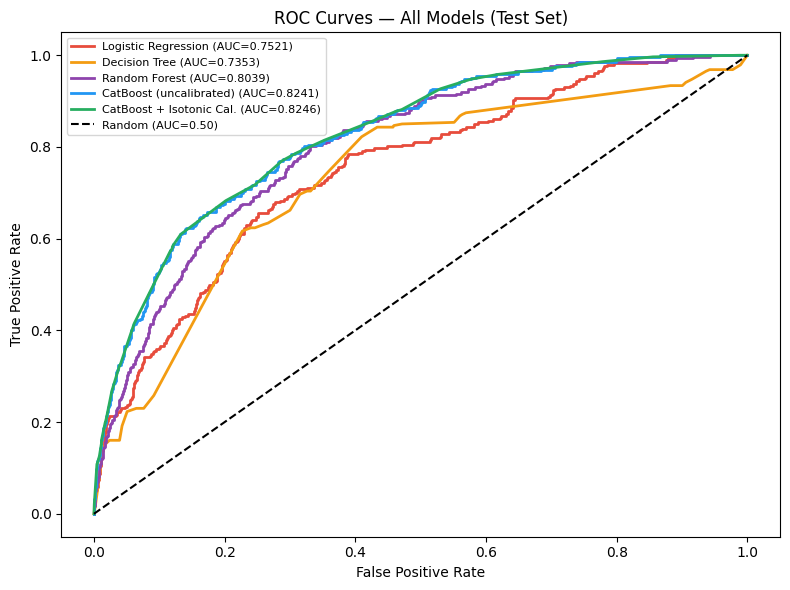

In [6]:
plt.figure(figsize=(8, 6))

colors = ['#E74C3C', '#F39C12', '#8E44AD', '#2196F3', '#27AE60']
for (label, proba), color in zip([
    ('Logistic Regression',      proba_lr),
    ('Decision Tree',            proba_dt),
    ('Random Forest',            proba_rf),
    ('CatBoost (uncalibrated)',  proba_cb_raw),
    ('CatBoost + Isotonic Cal.', proba_cb_cal),
], colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC={auc:.4f})')

plt.plot([0,1],[0,1],'k--', label='Random (AUC=0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models (Test Set)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Detailed Report — Best Model (CatBoost + Calibration)

In [7]:
final_preds = (proba_cb_cal >= THRESHOLD).astype(int)
print('=== CatBoost + Isotonic Calibration — Full Report ===')
print(classification_report(y_test, final_preds, target_names=['Alive', 'Failed']))

=== CatBoost + Isotonic Calibration — Full Report ===
              precision    recall  f1-score   support

       Alive       0.98      0.99      0.98     11995
      Failed       0.24      0.15      0.19       287

    accuracy                           0.97     12282
   macro avg       0.61      0.57      0.59     12282
weighted avg       0.96      0.97      0.97     12282

